### **Importación de Librerías**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import math

## **Presentación de Dataset**

In [53]:
df = pd.read_csv('https://raw.githubusercontent.com/ArianaAbrilMEDINA/Telecom2/main/datos_tratados.csv')
df.head(4)

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,No,Femenino,No,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Anual,Si,Cheque por correo,65.6,593.3,2.19
1,0003-MKNFE,No,Masculino,No,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mensual,No,Cheque por correo,59.9,542.4,2.00
2,0004-TLHLJ,Yes,Masculino,No,No,No,4,Si,No,Fibra optica,...,Si,No,No,No,Mensual,Si,Cheque electrónico,73.9,280.85,2.46
3,0011-IGKFF,Yes,Masculino,Si,Si,No,13,Si,No,Fibra optica,...,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.0,1237.85,3.27


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               7267 non-null   object 
 1   Evasion                  7043 non-null   object 
 2   Genero                   7267 non-null   object 
 3   Adulto_Mayor             7267 non-null   object 
 4   Pareja                   7267 non-null   object 
 5   Dependientes             7267 non-null   object 
 6   Antiguedad_Meses         7267 non-null   int64  
 7   Servicio_Telefonico      7267 non-null   object 
 8   Multiples_Lineas         7267 non-null   object 
 9   Servicio_Internet        7267 non-null   object 
 10  Seguridad_Online         7267 non-null   object 
 11  Copia_Seguridad_Online   7267 non-null   object 
 12  Proteccion_Dispositivo   7267 non-null   object 
 13  Soporte_Tecnico          7267 non-null   object 
 14  Streaming_TV            

## **Transformación del dataset**

In [55]:
df['Evasion'].isna().sum()


np.int64(224)

In [56]:
# Decidi convertir la variable 'Cargos_Totales' a valores numéricos
df['Cargos_Totales'] = pd.to_numeric(df['Cargos_Totales'], errors='coerce')

# Y reemplacé los datos nulos por la media ya que los datos nulos nos afectarían el análisis de los datos.
# ¿Por qué no eliminé los datos nulos? Creo que no es adecuado, desde mi perspectiva, ya que se estarían sesgando los datos.
df['Cargos_Totales'] = df['Cargos_Totales'].fillna(df['Cargos_Totales'].mean())

In [57]:
# Decidi aplicar OneHotEncoding para también poder visualizar las columnas que tenian strings.
#Aparte ví que se podía pasar a binarios ya que eran respuestas de si o no, que lo podemos tomar como verdadero o falso.

df_nuevo = df.copy()

# Mapeo de valores para las columnas binarias
valores_nuevos = {'Yes': 1, 'Si': 1, 'No': 0, 'No internet service': 0, 'Sin servicio telefonico': 0, 'Sin servicio de internet': 0}

columnas_nuevas = ['Evasion', 'Adulto_Mayor', 'Pareja', 'Dependientes', 'Servicio_Telefonico', 'Facturacion_Electronica', 'Seguridad_Online', 'Copia_Seguridad_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas','Multiples_Lineas'] # 'Sin servicio telefonico' lo pondre como 0

for col in columnas_nuevas:
    if col in df_nuevo.columns:
        df_nuevo[col] = df_nuevo[col].map(valores_nuevos)

# Para 'Genero', cambiamos 'Masculino' a 1 y 'Femenino' a 0
df_nuevo['Genero'] = df_nuevo['Genero'].map({'Masculino': 1, 'Femenino': 0})

In [58]:
categorical_cols_for_ohe = ['Contrato', 'Metodo_Pago', 'Servicio_Internet']

# Aplico One-Hot Encoding
df_nuevo = pd.get_dummies(df_nuevo, columns=categorical_cols_for_ohe, drop_first=False)

display(df_nuevo.head())

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Seguridad_Online,...,Contrato_Anual,Contrato_Doble,Contrato_Mensual,Metodo_Pago_Cheque electrónico,Metodo_Pago_Cheque por correo,Metodo_Pago_Tarjeta de credito,Metodo_Pago_Transferencia bancaria,Servicio_Internet_DSL,Servicio_Internet_Fibra optica,Servicio_Internet_No
0,0002-ORFBO,0.0,0,0,1,1,9,1,0,0,...,True,False,False,False,True,False,False,True,False,False
1,0003-MKNFE,0.0,1,0,0,0,9,1,1,0,...,False,False,True,False,True,False,False,True,False,False
2,0004-TLHLJ,1.0,1,0,0,0,4,1,0,0,...,False,False,True,True,False,False,False,False,True,False
3,0011-IGKFF,1.0,1,1,1,0,13,1,0,0,...,False,False,True,True,False,False,False,False,True,False
4,0013-EXCHZ,1.0,0,1,1,0,3,1,0,0,...,False,False,True,False,True,False,False,False,True,False


## **Matriz de Correlación**

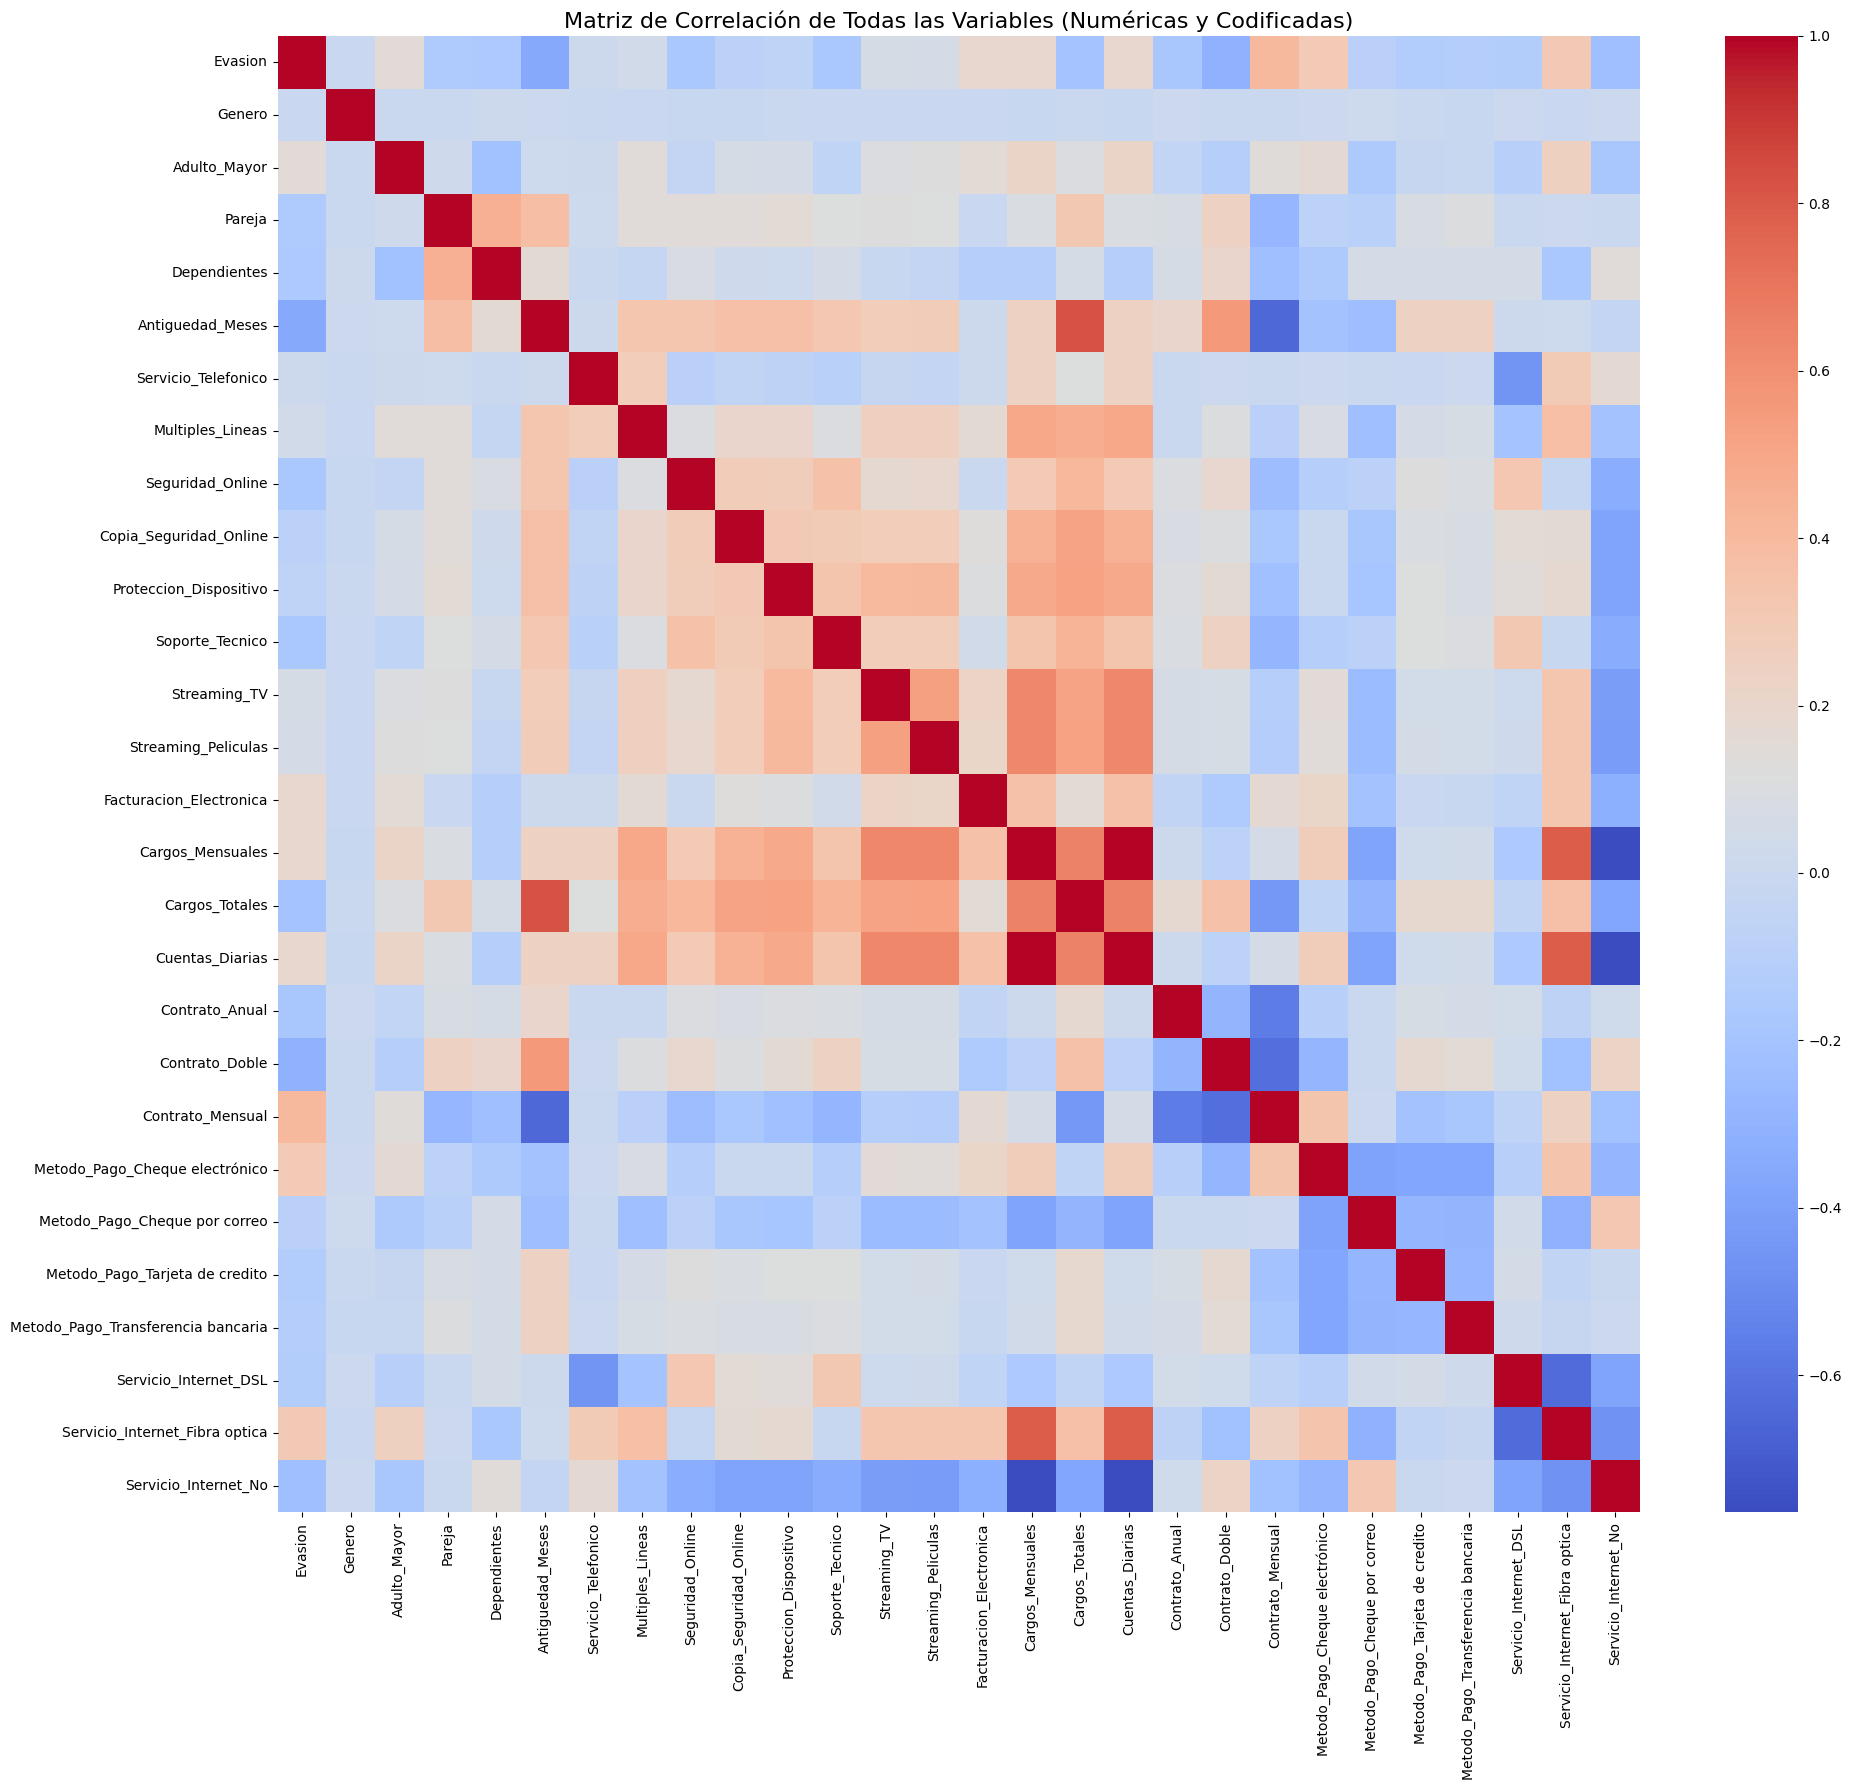

In [59]:
# Asegurarse de que 'ID_Cliente' no esté en el DataFrame codificado antes de calcular la correlación
if 'ID_Cliente' in df_nuevo.columns:
    df_nuevo = df_nuevo.drop('ID_Cliente', axis=1)

# Calcular la matriz de correlación para el DataFrame codificado
matriz = df_nuevo.corr()

plt.figure(figsize=(20, 18))
sns.heatmap(matriz, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Todas las Variables (Numéricas y Codificadas)', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [60]:
col_evasion = df['Evasion'].value_counts(normalize=True)

print("Proporción de clientes por estado de Evasion:")
print(col_evasion)

evasion_porcentaje = df['Evasion'].value_counts(normalize=True) * 100

print("\nPorcentaje de clientes por estado de Evasion:")
print(evasion_porcentaje)


proporcion_min = col_evasion.min()
proporcion_max = col_evasion.max()

if proporcion_max /proporcion_min > 2:
    print("\nExiste un desbalance significativo entre las clases de Evasion. Esto podría impactar en los modelos predictivos.")
else:
    print("\nEl desbalance entre las clases de Evasion no parece ser significativo para este umbral.")

Proporción de clientes por estado de Evasion:
Evasion
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Porcentaje de clientes por estado de Evasion:
Evasion
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Existe un desbalance significativo entre las clases de Evasion. Esto podría impactar en los modelos predictivos.


In [61]:
from scipy.stats import chi2_contingency

In [62]:
# Lista de columnas categóricas (sin incluir 'Evasion' que es la variable objetivo ni 'ID_Cliente')
col_categoricas = [col for col in df.select_dtypes(include='object').columns if col not in ['Evasion', 'ID_Cliente']]

print("Realizando pruebas de Chi-cuadrado para variables categóricas vs. Evasion:\n")

results_chi2 = {}

for col in col_categoricas :
    contingency_table = pd.crosstab(df[col], df['Evasion'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    results_chi2[col] = {'Chi2_Statistic': chi2, 'P_Value': p_value, 'Degrees_of_Freedom': dof}

    print(f"Variable: {col}")
    print(f"  Chi2 Statistic: {chi2:.4f}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  Degrees of Freedom: {dof}")
    if p_value < 0.05:
        print("  Conclusión: Hay una asociación significativa entre esta variable y Evasion (rechazar H0).")
    else:
        print("  Conclusión: No hay evidencia de asociación significativa entre esta variable y Evasion (no rechazar H0).")
    print("\n" + "-"*50 + "\n")

Realizando pruebas de Chi-cuadrado para variables categóricas vs. Evasion:

Variable: Genero
  Chi2 Statistic: 0.4841
  P-value: 0.4866
  Degrees of Freedom: 1
  Conclusión: No hay evidencia de asociación significativa entre esta variable y Evasion (no rechazar H0).

--------------------------------------------------

Variable: Adulto_Mayor
  Chi2 Statistic: 159.4263
  P-value: 0.0000
  Degrees of Freedom: 1
  Conclusión: Hay una asociación significativa entre esta variable y Evasion (rechazar H0).

--------------------------------------------------

Variable: Pareja
  Chi2 Statistic: 158.7334
  P-value: 0.0000
  Degrees of Freedom: 1
  Conclusión: Hay una asociación significativa entre esta variable y Evasion (rechazar H0).

--------------------------------------------------

Variable: Dependientes
  Chi2 Statistic: 189.1292
  P-value: 0.0000
  Degrees of Freedom: 1
  Conclusión: Hay una asociación significativa entre esta variable y Evasion (rechazar H0).

---------------------------

In [63]:
# Elimino las columnas basándonos en la prueba Chi-cuadrado (p-value > 0.05)
cols_a_eliminar = ['Genero', 'Servicio_Telefonico']

df = df.drop(columns=cols_a_eliminar, errors='ignore')

print(f"Columnas eliminadas: {cols_a_eliminar}")
df.head()

Columnas eliminadas: ['Genero', 'Servicio_Telefonico']


,ID_Cliente,Evasion,Adulto_Mayor,Pareja,Dependientes,Antiguedad_Meses,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Copia_Seguridad_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,No,No,Si,Si,9,No,DSL,No,Si,No,Si,Si,No,Anual,Si,Cheque por correo,65.6,593.30,2.19
1,0003-MKNFE,No,No,No,No,9,Si,DSL,No,No,No,No,No,Si,Mensual,No,Cheque por correo,59.9,542.40,2.00
2,0004-TLHLJ,Yes,No,No,No,4,No,Fibra optica,No,No,Si,No,No,No,Mensual,Si,Cheque electrónico,73.9,280.85,2.46
3,0011-IGKFF,Yes,Si,Si,No,13,No,Fibra optica,No,Si,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Si,Si,No,3,No,Fibra optica,No,No,No,Si,Si,No,Mensual,Si,Cheque por correo,83.9,267.40,2.80


# **Matriz correlativa numérica**

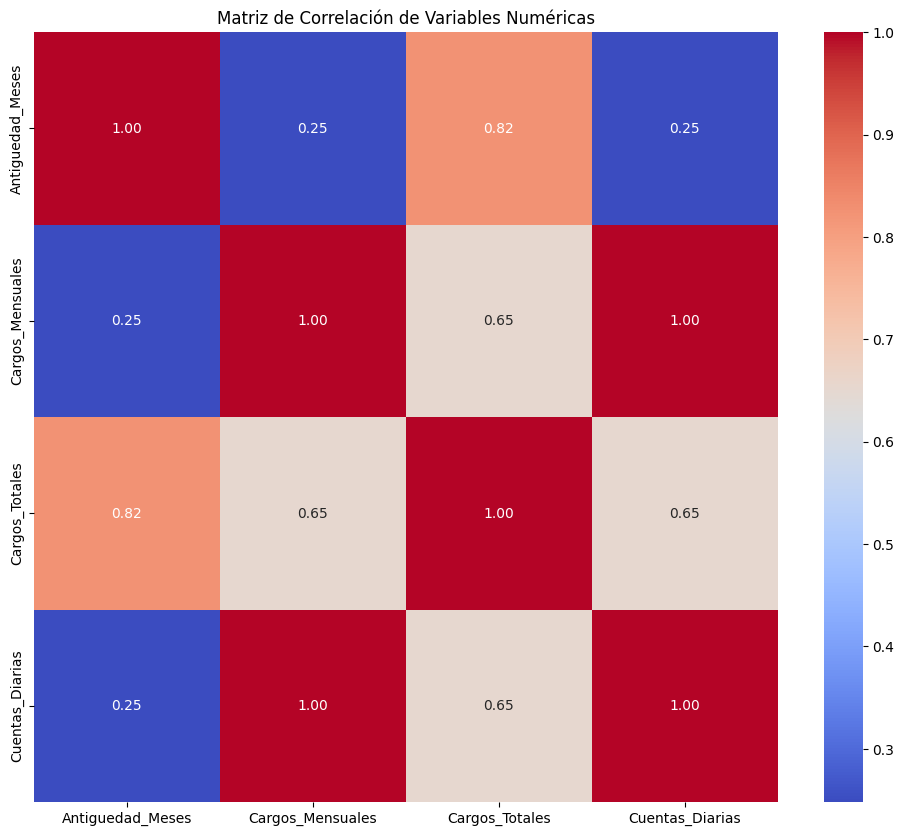

In [64]:
data = df.select_dtypes(include=[np.number])
matriz_numerica = data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_numerica, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

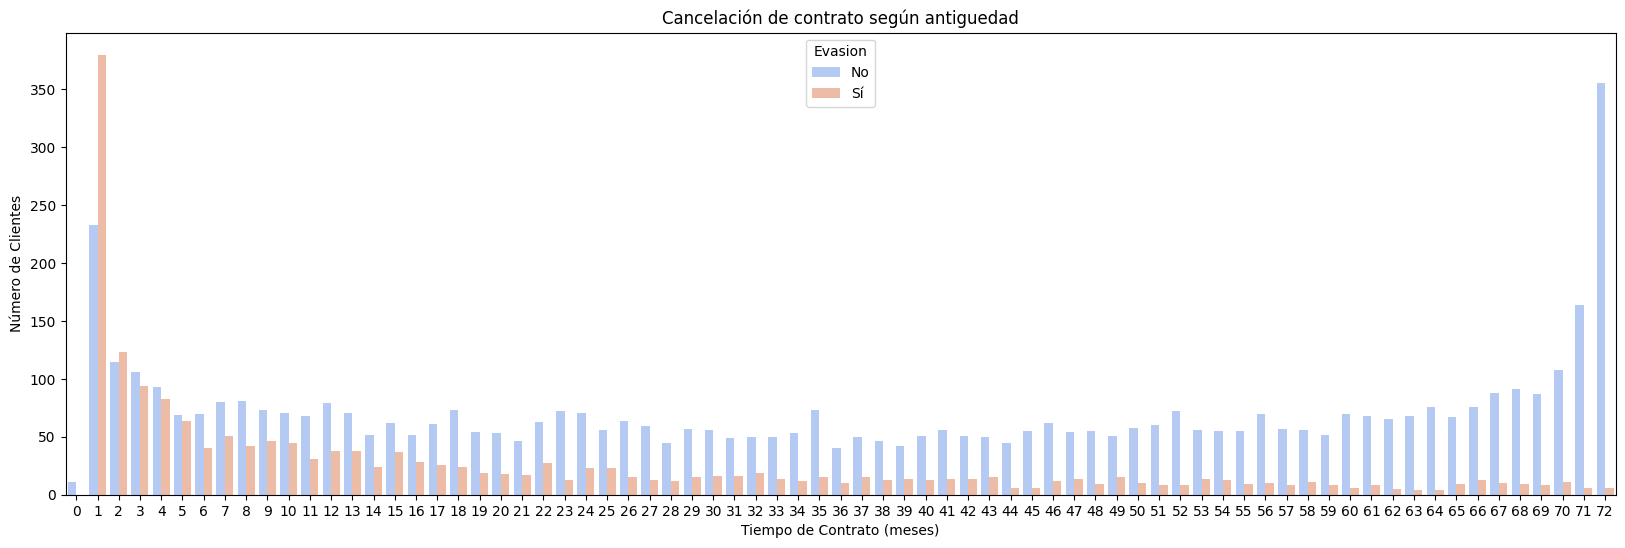

In [65]:
plt.figure(figsize=(20, 6))
sns.countplot(x='Antiguedad_Meses', hue='Evasion', data=df, palette='coolwarm')
plt.title('Cancelación de contrato según antiguedad')
plt.xlabel('Tiempo de Contrato (meses)')
plt.ylabel('Número de Clientes')
plt.legend(title='Evasion', labels=['No', 'Sí'])
plt.show()

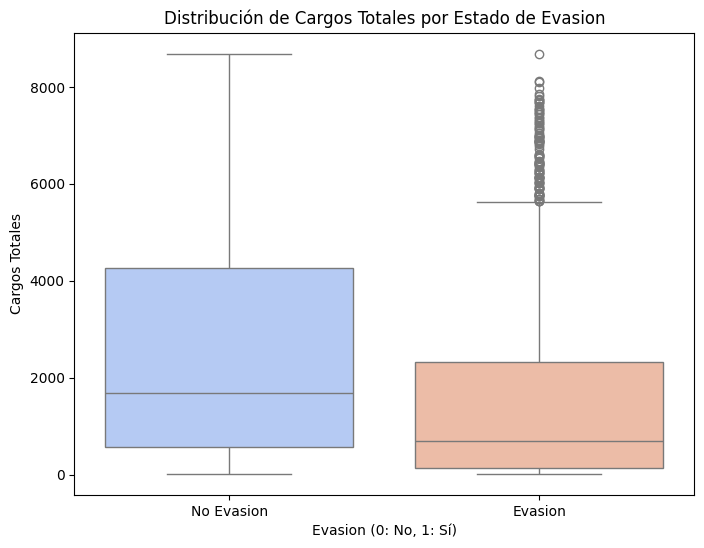

In [66]:
plt.figure(figsize=(8, 6))
# Corregimos la advertencia de FutureWarning: asignamos 'Evasion' a 'hue' para colorear por categoría
sns.boxplot(x='Evasion', y='Cargos_Totales', data=df_nuevo, hue='Evasion', palette='coolwarm', legend=False)
plt.title('Distribución de Cargos Totales por Estado de Evasion')
plt.xlabel('Evasion (0: No, 1: Sí)')
plt.ylabel('Cargos Totales')
plt.xticks(ticks=[0, 1], labels=['No Evasion', 'Evasion'])
plt.show()

#**Graficos: Evasión con otras variables**

In [67]:
non_numeric_cols = df.select_dtypes(exclude=np.number).columns.tolist()
if 'ID_Cliente' in non_numeric_cols:
    non_numeric_cols.remove('ID_Cliente')

print("Columnas no numéricas que podrían influir en la variable 'Evasion' (excluyendo 'ID_Cliente'):")
print(non_numeric_cols)

Columnas no numéricas que podrían influir en la variable 'Evasion' (excluyendo 'ID_Cliente'):
['Evasion', 'Adulto_Mayor', 'Pareja', 'Dependientes', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Copia_Seguridad_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Contrato', 'Facturacion_Electronica', 'Metodo_Pago']


Generando gráficos de barras apiladas para la proporción de Evasion por variable no numérica:


<Figure size 1000x600 with 0 Axes>

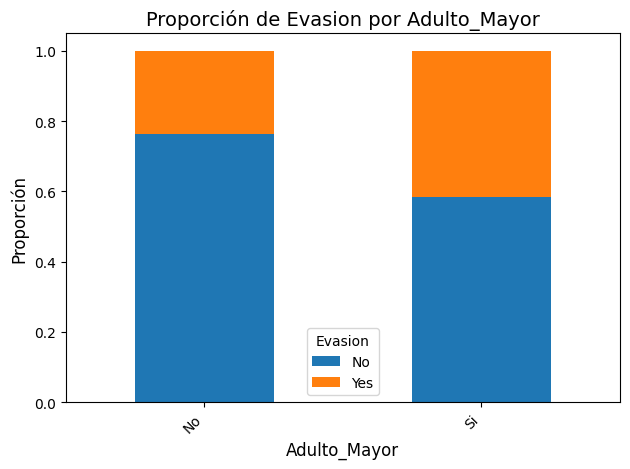

<Figure size 1000x600 with 0 Axes>

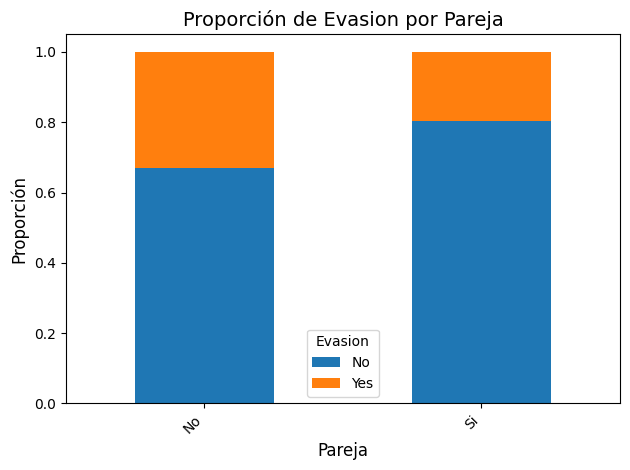

<Figure size 1000x600 with 0 Axes>

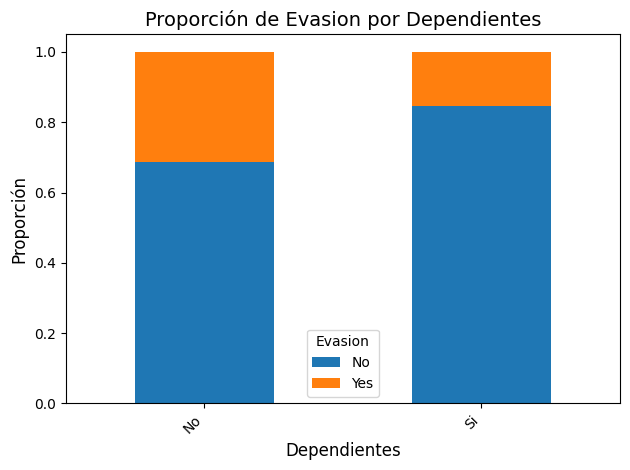

<Figure size 1000x600 with 0 Axes>

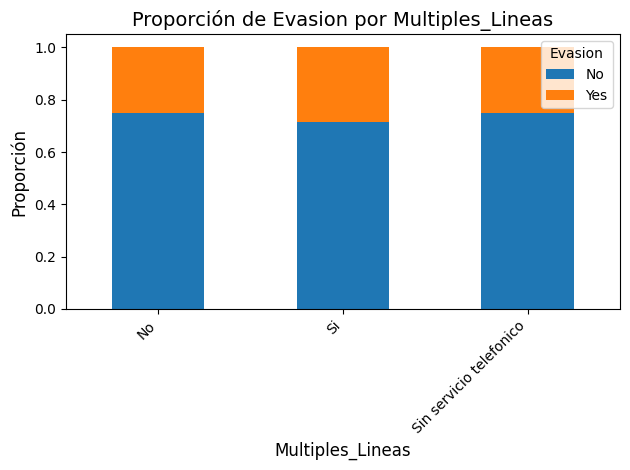

<Figure size 1000x600 with 0 Axes>

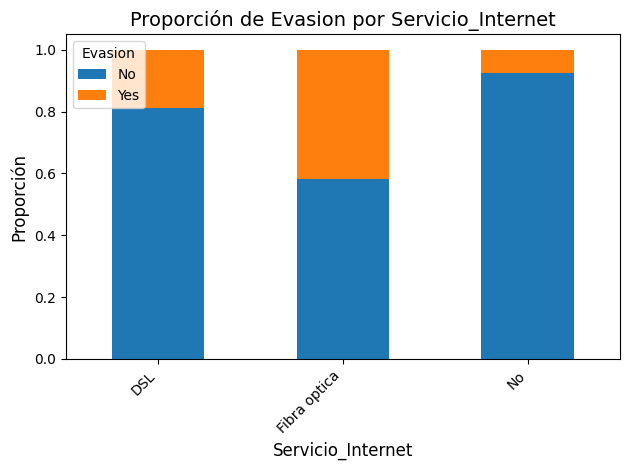

<Figure size 1000x600 with 0 Axes>

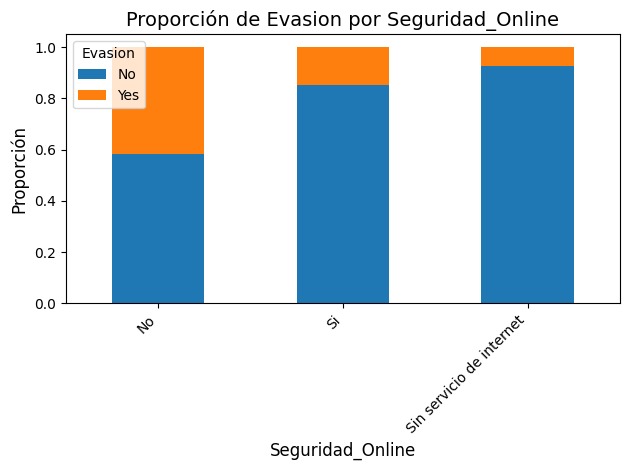

<Figure size 1000x600 with 0 Axes>

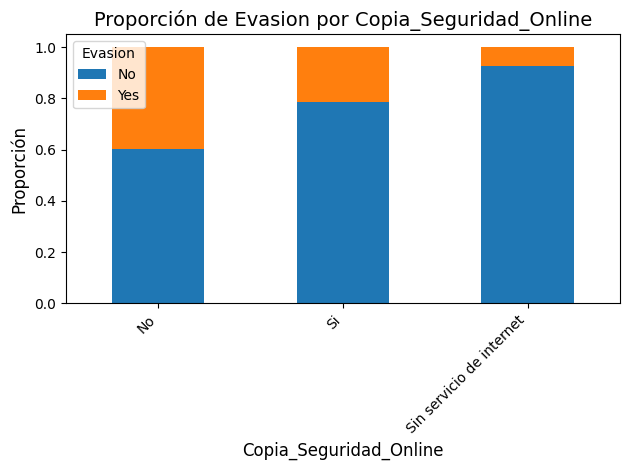

<Figure size 1000x600 with 0 Axes>

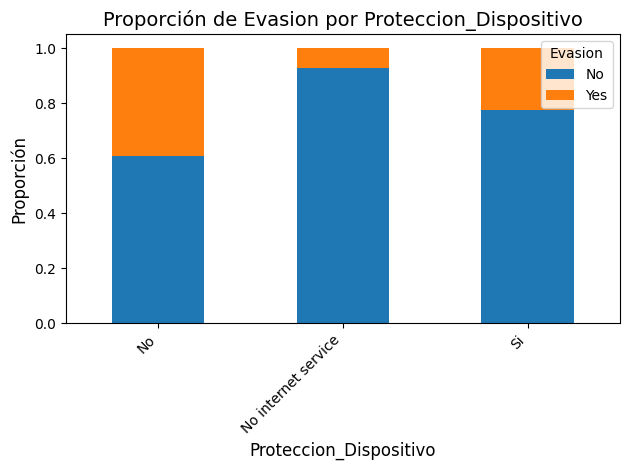

<Figure size 1000x600 with 0 Axes>

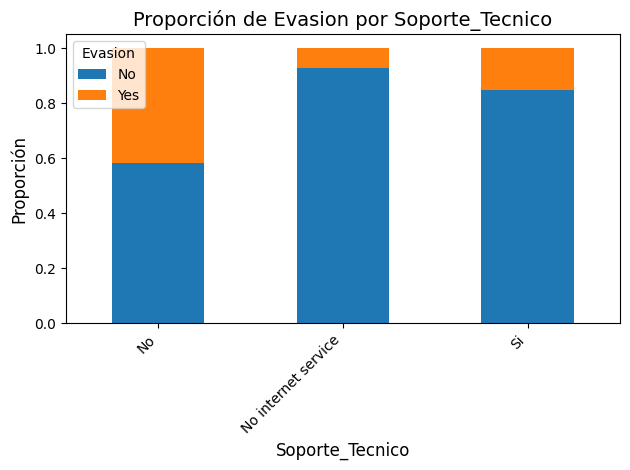

<Figure size 1000x600 with 0 Axes>

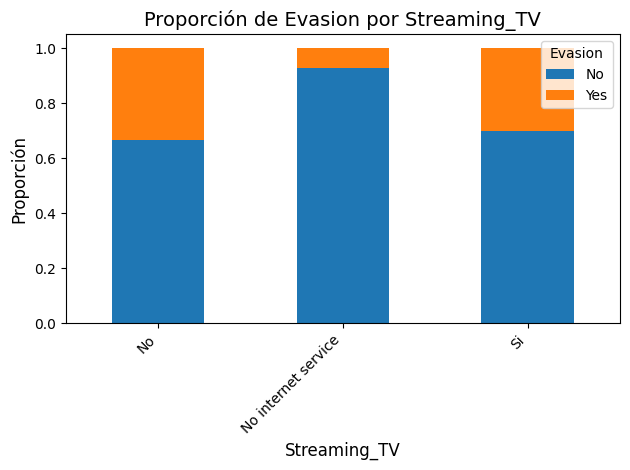

<Figure size 1000x600 with 0 Axes>

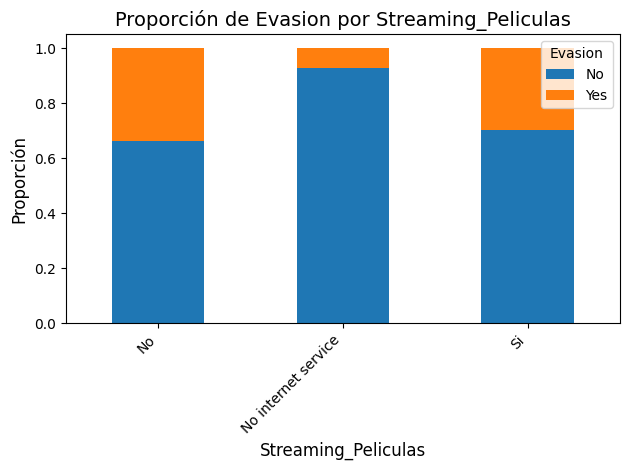

<Figure size 1000x600 with 0 Axes>

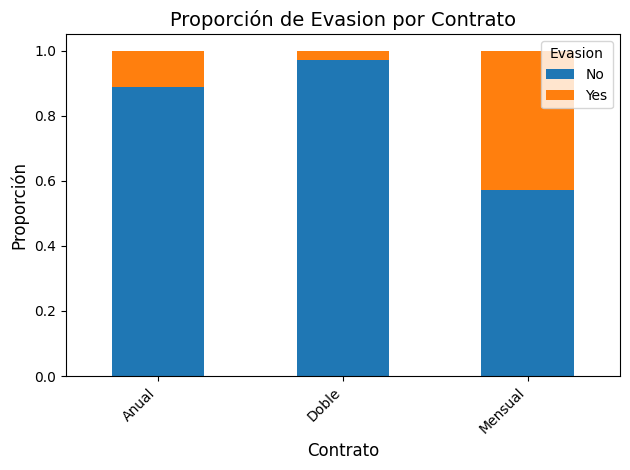

<Figure size 1000x600 with 0 Axes>

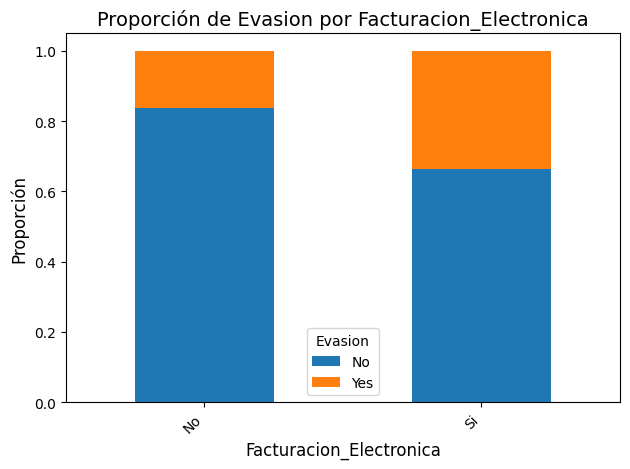

<Figure size 1000x600 with 0 Axes>

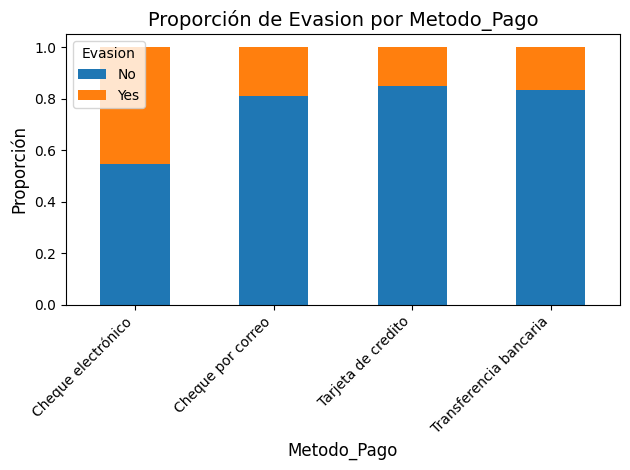

In [68]:
non_numeric_cols_for_plot = [col for col in non_numeric_cols if col not in ['Evasion', 'Cargos_Totales']]

print('Generando gráficos de barras apiladas para la proporción de Evasion por variable no numérica:')

for col in non_numeric_cols_for_plot:
    plt.figure(figsize=(10, 6))

    # Calculate proportions for Evasion (Yes/No) for each category
    df_plot = df.groupby([col, 'Evasion']).size().unstack(fill_value=0)
    df_plot = df_plot.apply(lambda x: x / x.sum(), axis=1) # Normalize to get proportions

    df_plot.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])

    plt.title(f'Proporción de Evasion por {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Proporción', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Evasion', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()


# **Modelo Ramdon Forest**

In [69]:
df_nuevo.head()

,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Seguridad_Online,Copia_Seguridad_Online,...,Contrato_Anual,Contrato_Doble,Contrato_Mensual,Metodo_Pago_Cheque electrónico,Metodo_Pago_Cheque por correo,Metodo_Pago_Tarjeta de credito,Metodo_Pago_Transferencia bancaria,Servicio_Internet_DSL,Servicio_Internet_Fibra optica,Servicio_Internet_No
0,0.0,0,0,1,1,9,1,0,0,1,...,True,False,False,False,True,False,False,True,False,False
1,0.0,1,0,0,0,9,1,1,0,0,...,False,False,True,False,True,False,False,True,False,False
2,1.0,1,0,0,0,4,1,0,0,0,...,False,False,True,True,False,False,False,False,True,False
3,1.0,1,1,1,0,13,1,0,0,1,...,False,False,True,True,False,False,False,False,True,False
4,1.0,0,1,1,0,3,1,0,0,0,...,False,False,True,False,True,False,False,False,True,False


In [74]:
df_model_uno = df_nuevo.copy()

# Eliminar filas con valores nulos en 'Evasion' antes de definir X y y
df_model_uno.dropna(subset=['Evasion'], inplace=True)

X = df_model_uno.drop('Evasion', axis=1)
y = df_model_uno['Evasion']

print(f"X (features): {X.shape}")
print(f"y (target): {y.shape}")

X (features): (7043, 27)
y (target): (7043,)


### División del Conjunto de Datos




In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (5634, 27)
X_test: (1409, 27)
y_train: (5634,)
y_test: (1409,)


In [76]:
from sklearn.ensemble import RandomForestClassifier

In [78]:
entrenando = RandomForestClassifier(random_state=42, class_weight='balanced')

entrenando.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

## **Analizemos el modelo Ramdon Forest.**

In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [83]:
y_pred = entrenando.predict(X_test)

# 2. Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nMatriz de Confusión:\n", conf_matrix)


Accuracy: 0.7885
Precision: 0.6404
Recall: 0.4584
F1-score: 0.5344

Matriz de Confusión:
 [[940  96]
 [202 171]]


In [84]:
feature_importances = entrenando.feature_importances_

features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

features_df = features_df.sort_values(by='Importance', ascending=False)

print("Top 10 Características Más Importantes:")
print(features_df.head(10))

Top 10 Características Más Importantes:
                           Feature  Importance
15                  Cargos_Totales    0.149337
4                 Antiguedad_Meses    0.134459
14                Cargos_Mensuales    0.124944
16                 Cuentas_Diarias    0.104269
19                Contrato_Mensual    0.098504
18                  Contrato_Doble    0.039897
20  Metodo_Pago_Cheque electrónico    0.034027
25  Servicio_Internet_Fibra optica    0.031394
0                           Genero    0.022075
13         Facturacion_Electronica    0.021236


# **Modelo KNN**

In [85]:
from sklearn.preprocessing import StandardScaler

In [86]:
scaler = StandardScaler()

X_train_2 = scaler.fit_transform(X_train)

X_test_2 = scaler.transform(X_test)

# 5. Convert both X_train_scaled and X_test_scaled back into pandas DataFrames
X_train_2 = pd.DataFrame(X_train_2, columns=X_train.columns, index=X_train.index)
X_test_2 = pd.DataFrame(X_test_2, columns=X_test.columns, index=X_test.index)

# 6. Print the first 5 rows of X_train_scaled and X_test_scaled
print("First 5 rows of X_train_scaled:\n")
display(X_train_2.head())

print("\nFirst 5 rows of X_test_scaled:\n")
display(X_test_2.head())

First 5 rows of X_train_scaled:



,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Seguridad_Online,Copia_Seguridad_Online,Proteccion_Dispositivo,...,Contrato_Anual,Contrato_Doble,Contrato_Mensual,Metodo_Pago_Cheque electrónico,Metodo_Pago_Cheque por correo,Metodo_Pago_Tarjeta de credito,Metodo_Pago_Transferencia bancaria,Servicio_Internet_DSL,Servicio_Internet_Fibra optica,Servicio_Internet_No
2197,0.984850,-0.447499,1.025530,1.531537,-1.191469,0.332215,-0.848708,1.582318,1.372340,-0.728397,...,-0.514714,-0.563822,0.905735,1.411957,-0.543024,-0.535346,-0.524081,-0.725260,1.126107,-0.52243
1665,0.984850,-0.447499,-0.975106,-0.652939,0.147103,0.332215,1.178261,-0.631984,-0.728683,-0.728397,...,-0.514714,-0.563822,0.905735,1.411957,-0.543024,-0.535346,-0.524081,-0.725260,1.126107,-0.52243
6255,-1.015383,-0.447499,1.025530,1.531537,0.674420,0.332215,1.178261,-0.631984,-0.728683,-0.728397,...,-0.514714,-0.563822,0.905735,1.411957,-0.543024,-0.535346,-0.524081,-0.725260,1.126107,-0.52243
1402,-1.015383,-0.447499,-0.975106,-0.652939,-1.029218,0.332215,-0.848708,-0.631984,-0.728683,-0.728397,...,-0.514714,-0.563822,0.905735,1.411957,-0.543024,-0.535346,-0.524081,-0.725260,1.126107,-0.52243
6962,-1.015383,-0.447499,1.025530,-0.652939,-1.232032,0.332215,-0.848708,-0.631984,-0.728683,-0.728397,...,-0.514714,-0.563822,0.905735,1.411957,-0.543024,-0.535346,-0.524081,1.378816,-0.888015,-0.52243



First 5 rows of X_test_scaled:



,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Seguridad_Online,Copia_Seguridad_Online,Proteccion_Dispositivo,...,Contrato_Anual,Contrato_Doble,Contrato_Mensual,Metodo_Pago_Cheque electrónico,Metodo_Pago_Cheque por correo,Metodo_Pago_Tarjeta de credito,Metodo_Pago_Transferencia bancaria,Servicio_Internet_DSL,Servicio_Internet_Fibra optica,Servicio_Internet_No
190,0.984850,-0.447499,-0.975106,-0.652939,-0.015148,0.332215,-0.848708,-0.631984,-0.728683,-0.728397,...,-0.514714,1.773611,-1.104076,-0.708237,-0.543024,-0.535346,1.908103,-0.725260,-0.888015,1.914134
2787,0.984850,-0.447499,1.025530,1.531537,1.607364,0.332215,1.178261,1.582318,-0.728683,1.372877,...,1.942827,-0.563822,-1.104076,-0.708237,-0.543024,-0.535346,1.908103,-0.725260,1.126107,-0.522430
3935,-1.015383,-0.447499,1.025530,1.531537,1.566801,0.332215,1.178261,1.582318,1.372340,1.372877,...,-0.514714,1.773611,-1.104076,-0.708237,1.841540,-0.535346,-0.524081,1.378816,-0.888015,-0.522430
1854,-1.015383,-0.447499,1.025530,-0.652939,-1.191469,0.332215,-0.848708,-0.631984,-0.728683,-0.728397,...,-0.514714,-0.563822,0.905735,-0.708237,1.841540,-0.535346,-0.524081,1.378816,-0.888015,-0.522430
136,0.984850,-0.447499,1.025530,1.531537,-0.988655,0.332215,-0.848708,-0.631984,-0.728683,-0.728397,...,-0.514714,1.773611,-1.104076,-0.708237,1.841540,-0.535346,-0.524081,-0.725260,-0.888015,1.914134


In [87]:
from sklearn.neighbors import KNeighborsClassifier

In [89]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_2, y_train)

KNeighborsClassifier()

## **Analizemos el modelo KNN**


In [93]:
y_pred_knn = knn.predict(X_test_2)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
presicion_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
matriz_conf_knn = confusion_matrix(y_test, y_pred_knn)

print(f"KNN Accuracy: {accuracy_knn:.4f}")
print(f"KNN Presicion: {presicion_knn:.4f}")
print(f"KNN Recall: {recall_knn:.4f}")
print(f"KNN F1-score: {f1_knn:.4f}")
print("\nKNN Matriz de Confusion:\n", matriz_conf_knn)

KNN Accuracy: 0.7516
KNN Presicion: 0.5319
KNN Recall: 0.5147
KNN F1-score: 0.5232

KNN Matriz de Confusion:
 [[867 169]
 [181 192]]


# **Comparemos ambos modelos**

In [97]:
print("--- Análisis de Rendimiento General ---")
if f1 > f1_knn:
    print(f"El modelo con mejor rendimiento general (basado en F1-score) es Random Forest con un F1-score de {f1:.4f}.")
elif f1_knn > f1:
    print(f"El modelo con mejor rendimiento general (basado en F1-score) es KNN con un F1-score de {f1_knn:.4f}.")
else:
    print(f"Ambos modelos tienen un rendimiento similar (basado en F1-score) de {f1:.4f}.")

--- Análisis de Rendimiento General ---
El modelo con mejor rendimiento general (basado en F1-score) es Random Forest con un F1-score de 0.5344.


#**Informe**

En esta ocasión, seguimos analizando el mismo dataframe que el desafio anterior pero ya transformado (lo hicimos en el desafio 1). El objetivo de este desafio era aplicar los conocimientos de machine learning adquiridos en esta etapa e identificar los patrones que llevan a los clientes a cancelar sus servicios (Evasión) y evaluar modelos para predecir estos comportamientos de manera anticipada.

Decidí aplicar dos modelos: Random Forest y KNN. Los elegí ya que, con el primero, ya habia trabajado en la universidad para un analisis de garrafas y, el segundo, era algo nuevo que quería probar.

Luego de aplicar ambos modelos, se decidió centrarnos en el analisís del rendimiento de cada modelo. Se observó que ambos tuvieron un buen rendimiento.
- **Random Forest :** Logró un Accuracy de **0.7885** y una precisión de **0.6437**. Esto significa que cuando el modelo marca a un cliente como "posible baja", tiene un 64% de acierto. Su punto débil es el *Recall* (0.4504), indicando que no acapara a todos los clientes que realmente terminan cancelando.
- **KNN :** Aunque su precisión es menor (0.5636), su *Recall* es superior (**0.4987**). Es decir que detecta a más clientes en riesgo, pero genera más falsos positivos.

Luego de analizar las matrices de correlación y analizar la importancia de las variables, se notó que los factores claves que estarían influyendo en la evasión serían los siguentes:

- La antiguedad del cliente ya que hay una fuerte correlación, o sea, que los cleintes que no son antiguos tienden a evadir.
- El tipo de contrato debido a que los que poseen un contrato mensual tienden a evadir mucho más que los anuales.
- El servicio de internet. Se ve que los clientes que contratan o tienen fibra óptica tienden a evadir, podría deberse a que no funciona correctamente o que eligen otra opcion mejor.
- Los cargos mensuales: los cleintes que tienen más cargos evaden más.
- Finalmente, el método de pago, los cleintes que usan cheque electrónico tienen una fuerte tendencia a evadir.

Finalmente, El Random Forest es el mejor modelo general por su alta precisión, aunque se equivoca poco al señalar a un sospechoso de fuga. Sin embargo, el KNN es ligeramente mejor detectando a más clientes en riesgo Recall, aunque genera falsos positivos, que se pueden observar en la matriz de confusion.

Para concluir, basandome en el análisis se debería seguir a los clientes nuevos dentro de los primeros 6 meses para observar que es lo que anda mal y, así, evitar la evasión/ la baja de contratos. También, se debería dejar de ofrecer firmar contratos mensuales y cambiarlos por anuales. Además se podría mejorar el servicio de fibra óptica o analizar que es lo que no los satisface a los nuevos clientes, quizas el precio. Por último, cre que se debería cambiar el método de pago, ya no se tendría que aceptar los cheque eletrónicos.